# These datasets have shown ROC-AUC of 1

I suspect that some of the features separate the classes almost entirely.

In [2]:
import sys
sys.path.insert(1, '../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import roc_auc_score
from functions.data import load_dataset

warnings.filterwarnings("ignore", message="Could not infer format")

In [3]:
datasets = [
    "dermatology-6",
    "arrhythmia",
    "car_eval_4",
    "libras_move",
    "kddcup-buffer_overflow_vs_back",
    "kr-vs-k-one_vs_fifteen",
    "page-blocks-1-3_vs_4",
    "shuttle-2_vs_5",
]

## Find features that split classes perfectly

In [4]:
threshold = 0.90  # AUC above this (or below 1 - this) means near-perfect separation

for dataset in datasets:
    X_train, X_test, y_train, y_test = load_dataset(dataset)
    print(f"\n{dataset}:")

    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    
    if good_features:
        for feat, auc in sorted(good_features, key=lambda x: x[1], reverse=True):
            print(f"  Feature {feat}: AUC = {auc}")
    else:
        print("  No features with near-perfect separation found.")


dermatology-6:
  Feature 30: AUC = 1.0
  Feature 6: AUC = 0.995
  Feature 33: AUC = 0.983
  Feature 29: AUC = 0.953

arrhythmia:
  Feature x13: AUC = 0.982

car_eval_4:
  No features with near-perfect separation found.

libras_move:
  No features with near-perfect separation found.

kddcup-buffer_overflow_vs_back:
  Feature 2: AUC = 1.0
  Feature 4: AUC = 1.0
  Feature 35: AUC = 0.996
  Feature 31: AUC = 0.995
  Feature 5: AUC = 0.993
  Feature 32: AUC = 0.987
  Feature 23: AUC = 0.903

kr-vs-k-one_vs_fifteen:
  Feature 5: AUC = 0.973
  Feature 1: AUC = 0.926
  Feature 4: AUC = 0.912

page-blocks-1-3_vs_4:
  Feature 0: AUC = 0.946
  Feature 9: AUC = 0.943
  Feature 8: AUC = 0.931
  Feature 7: AUC = 0.923

shuttle-2_vs_5:
  Feature 6: AUC = 1.0
  Feature 0: AUC = 0.999
  Feature 1: AUC = 0.994
  Feature 2: AUC = 0.962


These 3 datasets have features that split classes perfectly:
    
- dermatology-6
- kddcup-buffer_overflow_vs_back
- shuttle-2_vs_5

In [9]:
for dataset in datasets:
    if dataset not in ["dermatology-6", "kddcup-buffer_overflow_vs_back", "shuttle-2_vs_5"]:
        X_train, X_test, y_train, y_test = load_dataset(dataset)
        print(f"\n{dataset}:")
        
        good_features = []
        for j in range(X_test.shape[1]):
            col = X_test.iloc[:, j] if hasattr(X_test, "iloc") else X_test[:, j]
            auc = roc_auc_score(y_test, col)
            auc = max(auc, 1 - auc)
            if auc >= threshold:
                feat_name = X_test.columns[j] if hasattr(X_test, "columns") else j
                good_features.append((feat_name, round(auc, 3)))
        
        if good_features:
            for feat, auc in sorted(good_features, key=lambda x: x[1], reverse=True):
                print(f"  Feature {feat}: AUC = {auc}")
        else:
            print("  No features with near-perfect separation found.")


arrhythmia:
  Feature x13: AUC = 0.99

car_eval_4:
  No features with near-perfect separation found.

libras_move:
  Feature 27: AUC = 0.905

kr-vs-k-one_vs_fifteen:
  Feature 5: AUC = 0.984
  Feature 1: AUC = 0.946
  Feature 4: AUC = 0.936

page-blocks-1-3_vs_4:
  Feature 7: AUC = 0.95
  Feature 0: AUC = 0.946
  Feature 8: AUC = 0.94
  Feature 2: AUC = 0.908


These 2 datasets have features with almost perfect separation in the test set:

- arrhythmia
- kr-vs-k-one_vs_fifteen:

> ⚠️ **Conclusion**: Some datasets contain features that already separate the two classes almost perfectly (AUC ≥ 0.90). Training models on these datasets is redundant — if a single raw feature does the job, there is no need for a complex classifier. **These datasets will be removed from the analysis.**

In [11]:
# Datasets to remove:

datasets = [
    "dermatology-6",
    "arrhythmia",
    "kddcup-buffer_overflow_vs_back",
    "kr-vs-k-one_vs_fifteen",
    "shuttle-2_vs_5",
]

## Plot features that split classes 

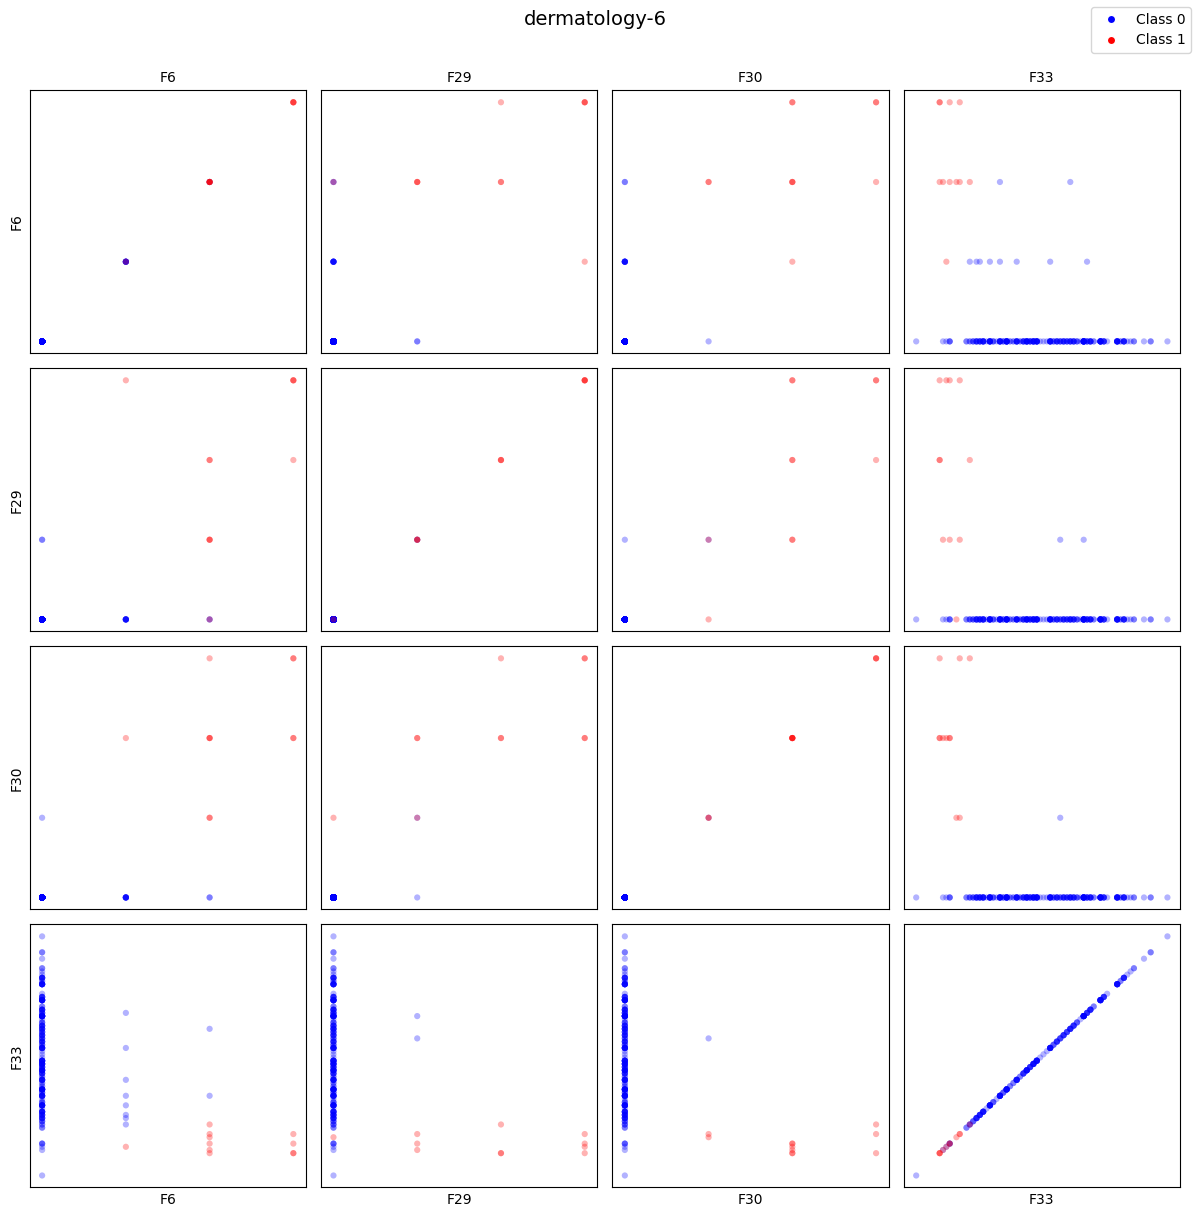

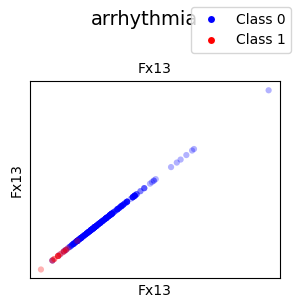

car_eval_4: no good features, skipping.
libras_move: no good features, skipping.


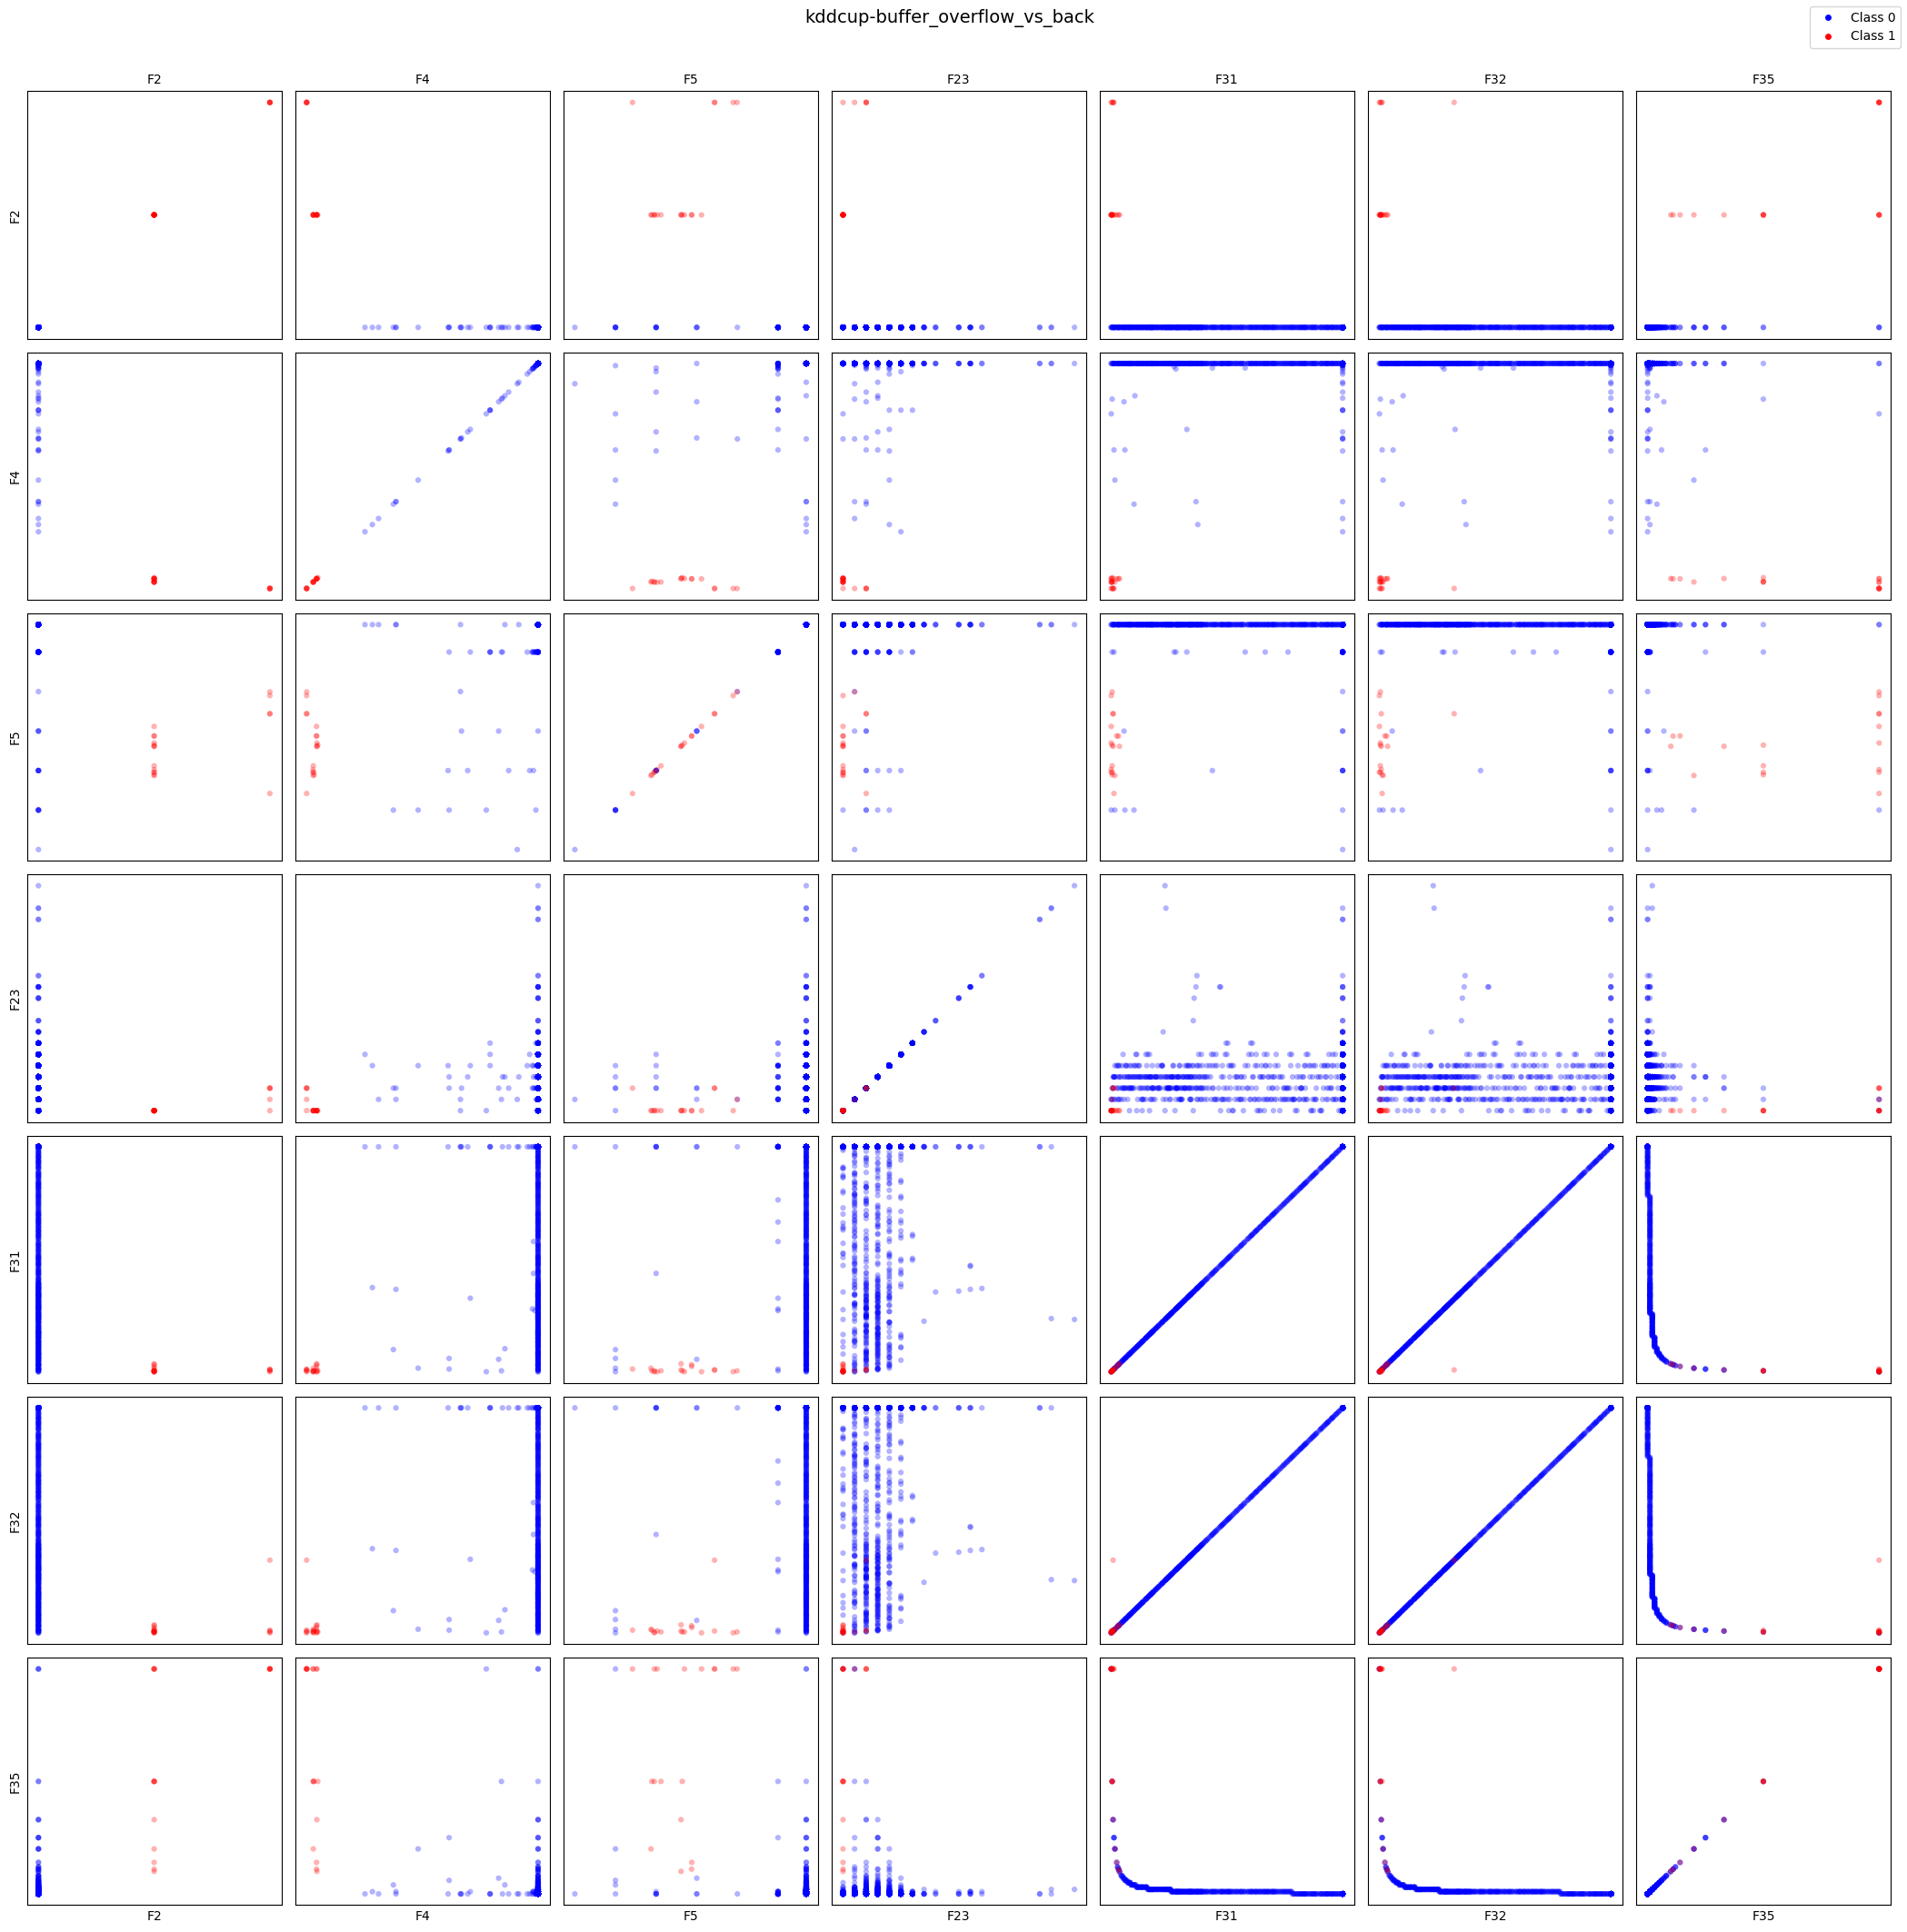

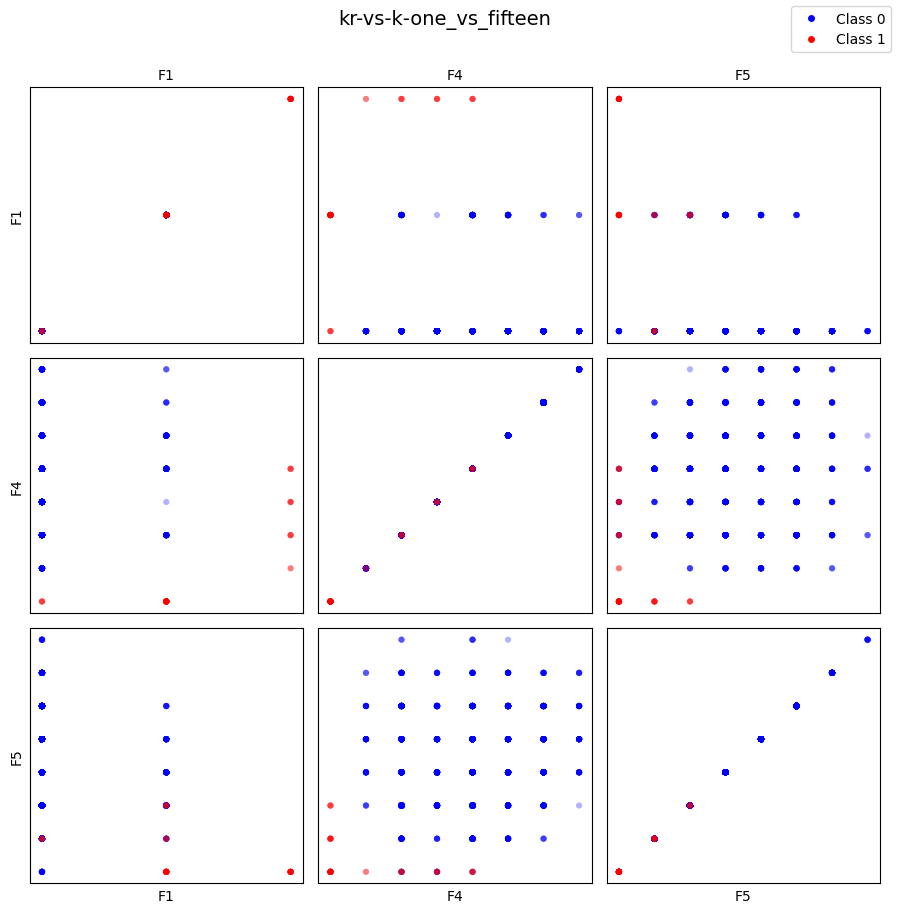

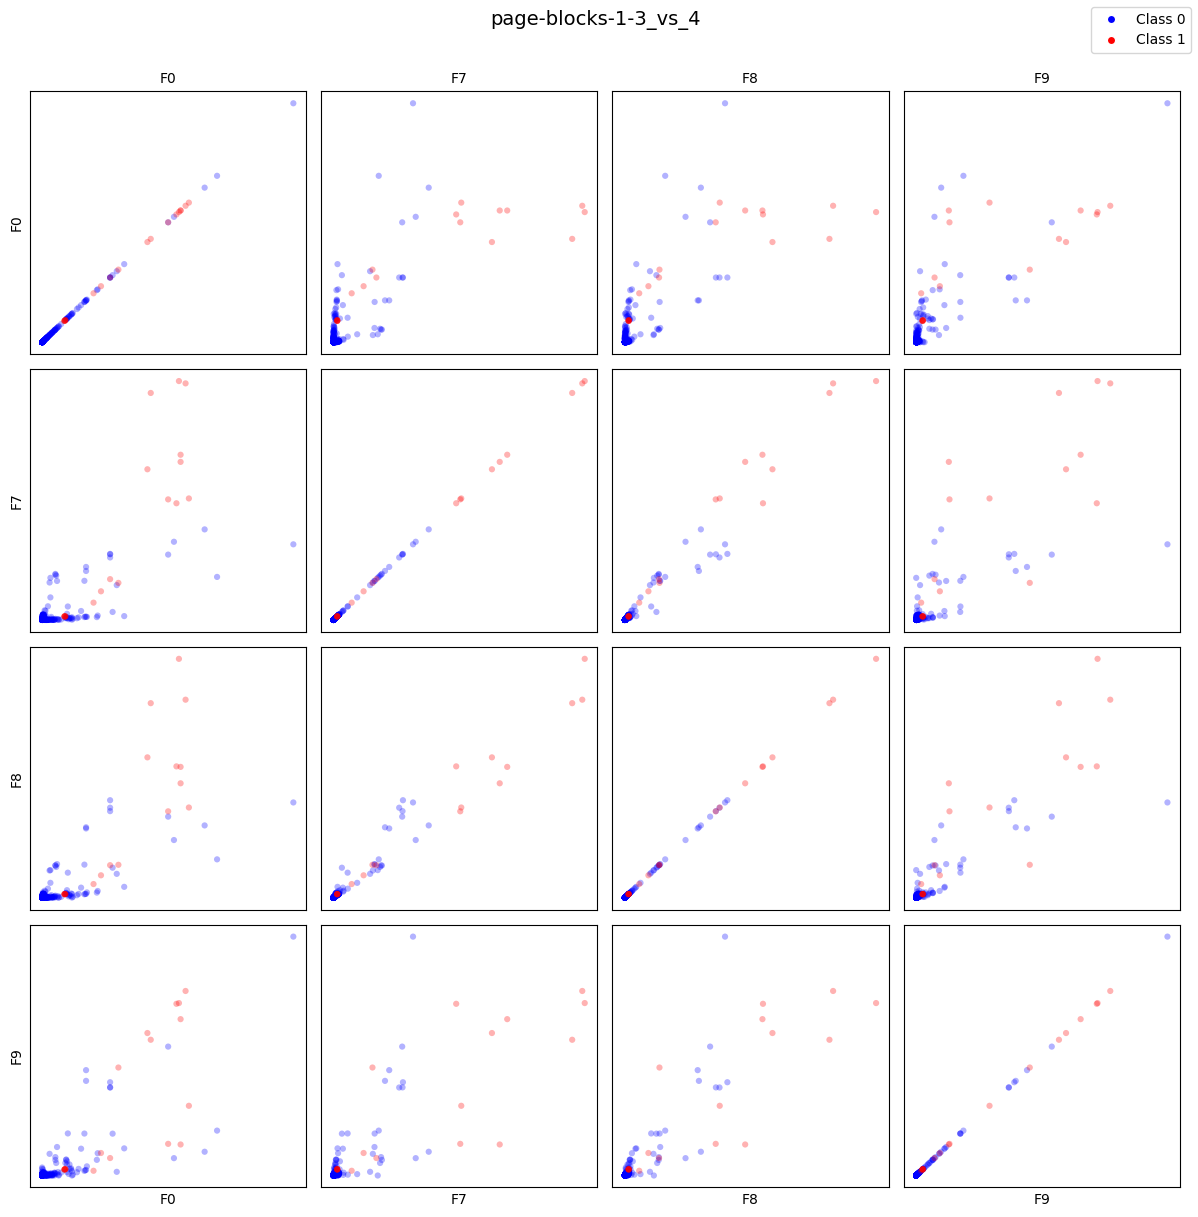

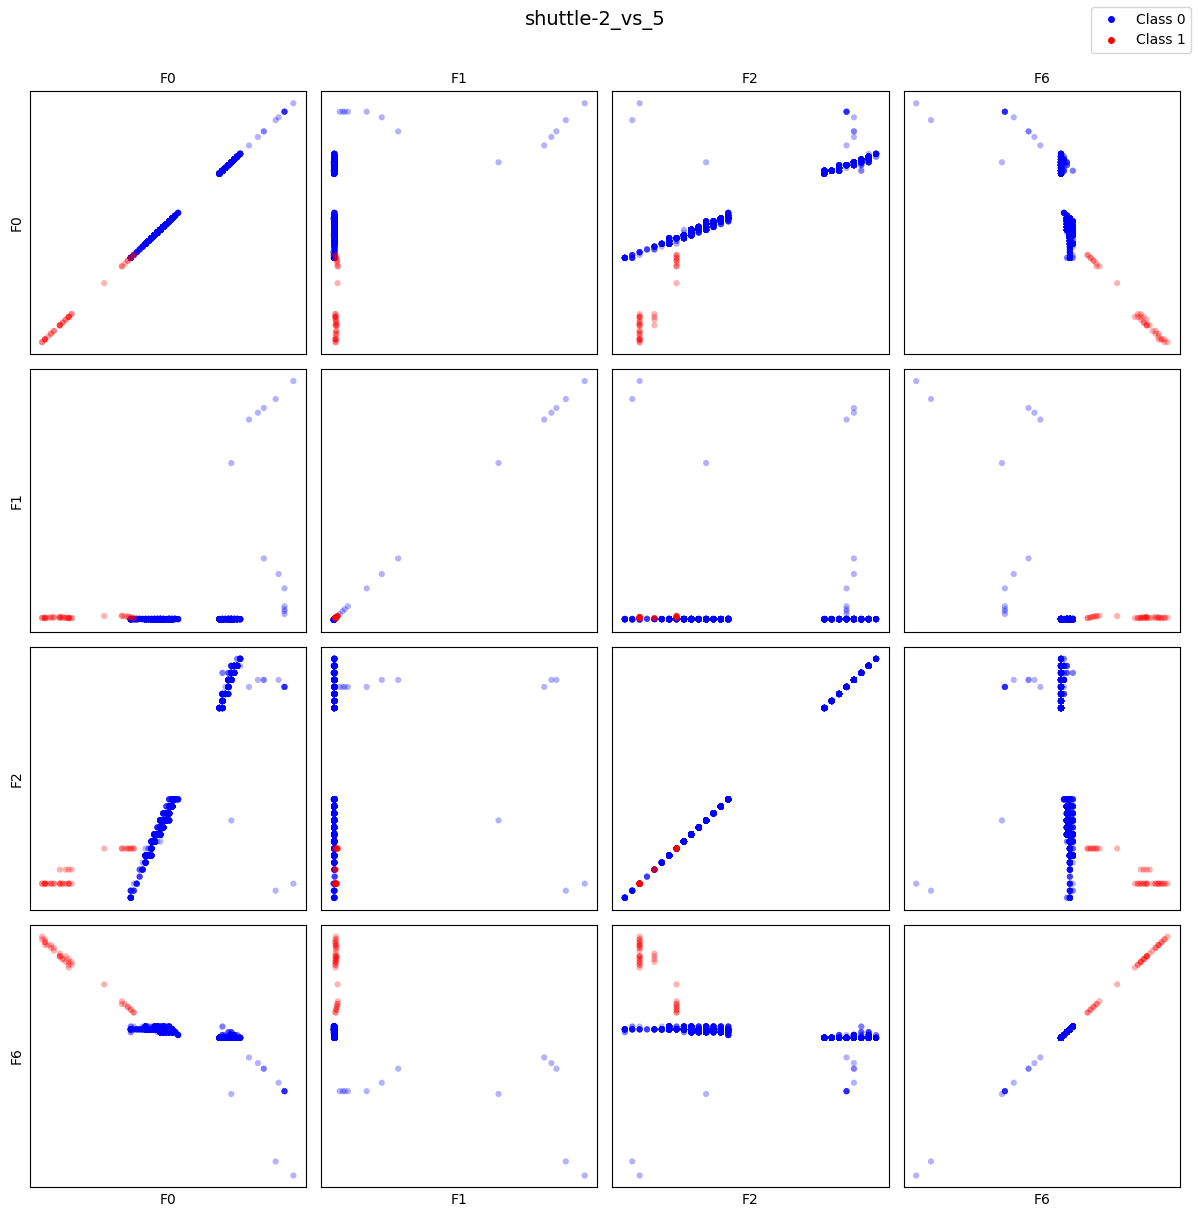

In [6]:
for dataset in datasets:
    X_train, X_test, y_train, y_test = load_dataset(dataset)
    
    # find good features
    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    if not good_features:
        print(f"{dataset}: no good features, skipping.")
        continue

    # Scatter plots
    feat_names = [f[0] for f in good_features]
    n = len(feat_names)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    if n == 1:
        axes = np.array([[axes]])
    for i, fi in enumerate(feat_names):
        for j, fj in enumerate(feat_names):
            ax = axes[i, j]
            for label, color in zip([0, 1], ["blue", "red"]):
                mask = y_train == label
                xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
                xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
                ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
            if i == n - 1:
                ax.set_xlabel(f"F{fj}", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"F{fi}", fontsize=10)
            if i == 0:
                ax.set_title(f"F{fj}", fontsize=10)
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
               for l, c in zip([0, 1], ["blue", "red"])]
    fig.legend(handles=handles, loc="upper right", fontsize=10)
    plt.suptitle(f"{dataset}", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

In [5]:
threshold = 0.90  # AUC above this (or below 1 - this) means near-perfect separation

datasets = ["protein_homo"]

for dataset in datasets:
    X_train, X_test, y_train, y_test = load_dataset(dataset)
    print(f"\n{dataset}:")

    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    
    if good_features:
        for feat, auc in sorted(good_features, key=lambda x: x[1], reverse=True):
            print(f"  Feature {feat}: AUC = {auc}")
    else:
        print("  No features with near-perfect separation found.")


protein_homo:
  Feature 52: AUC = 0.943
  Feature 54: AUC = 0.938
  Feature 4: AUC = 0.927
  Feature 2: AUC = 0.919
  Feature 57: AUC = 0.914
  Feature 34: AUC = 0.911


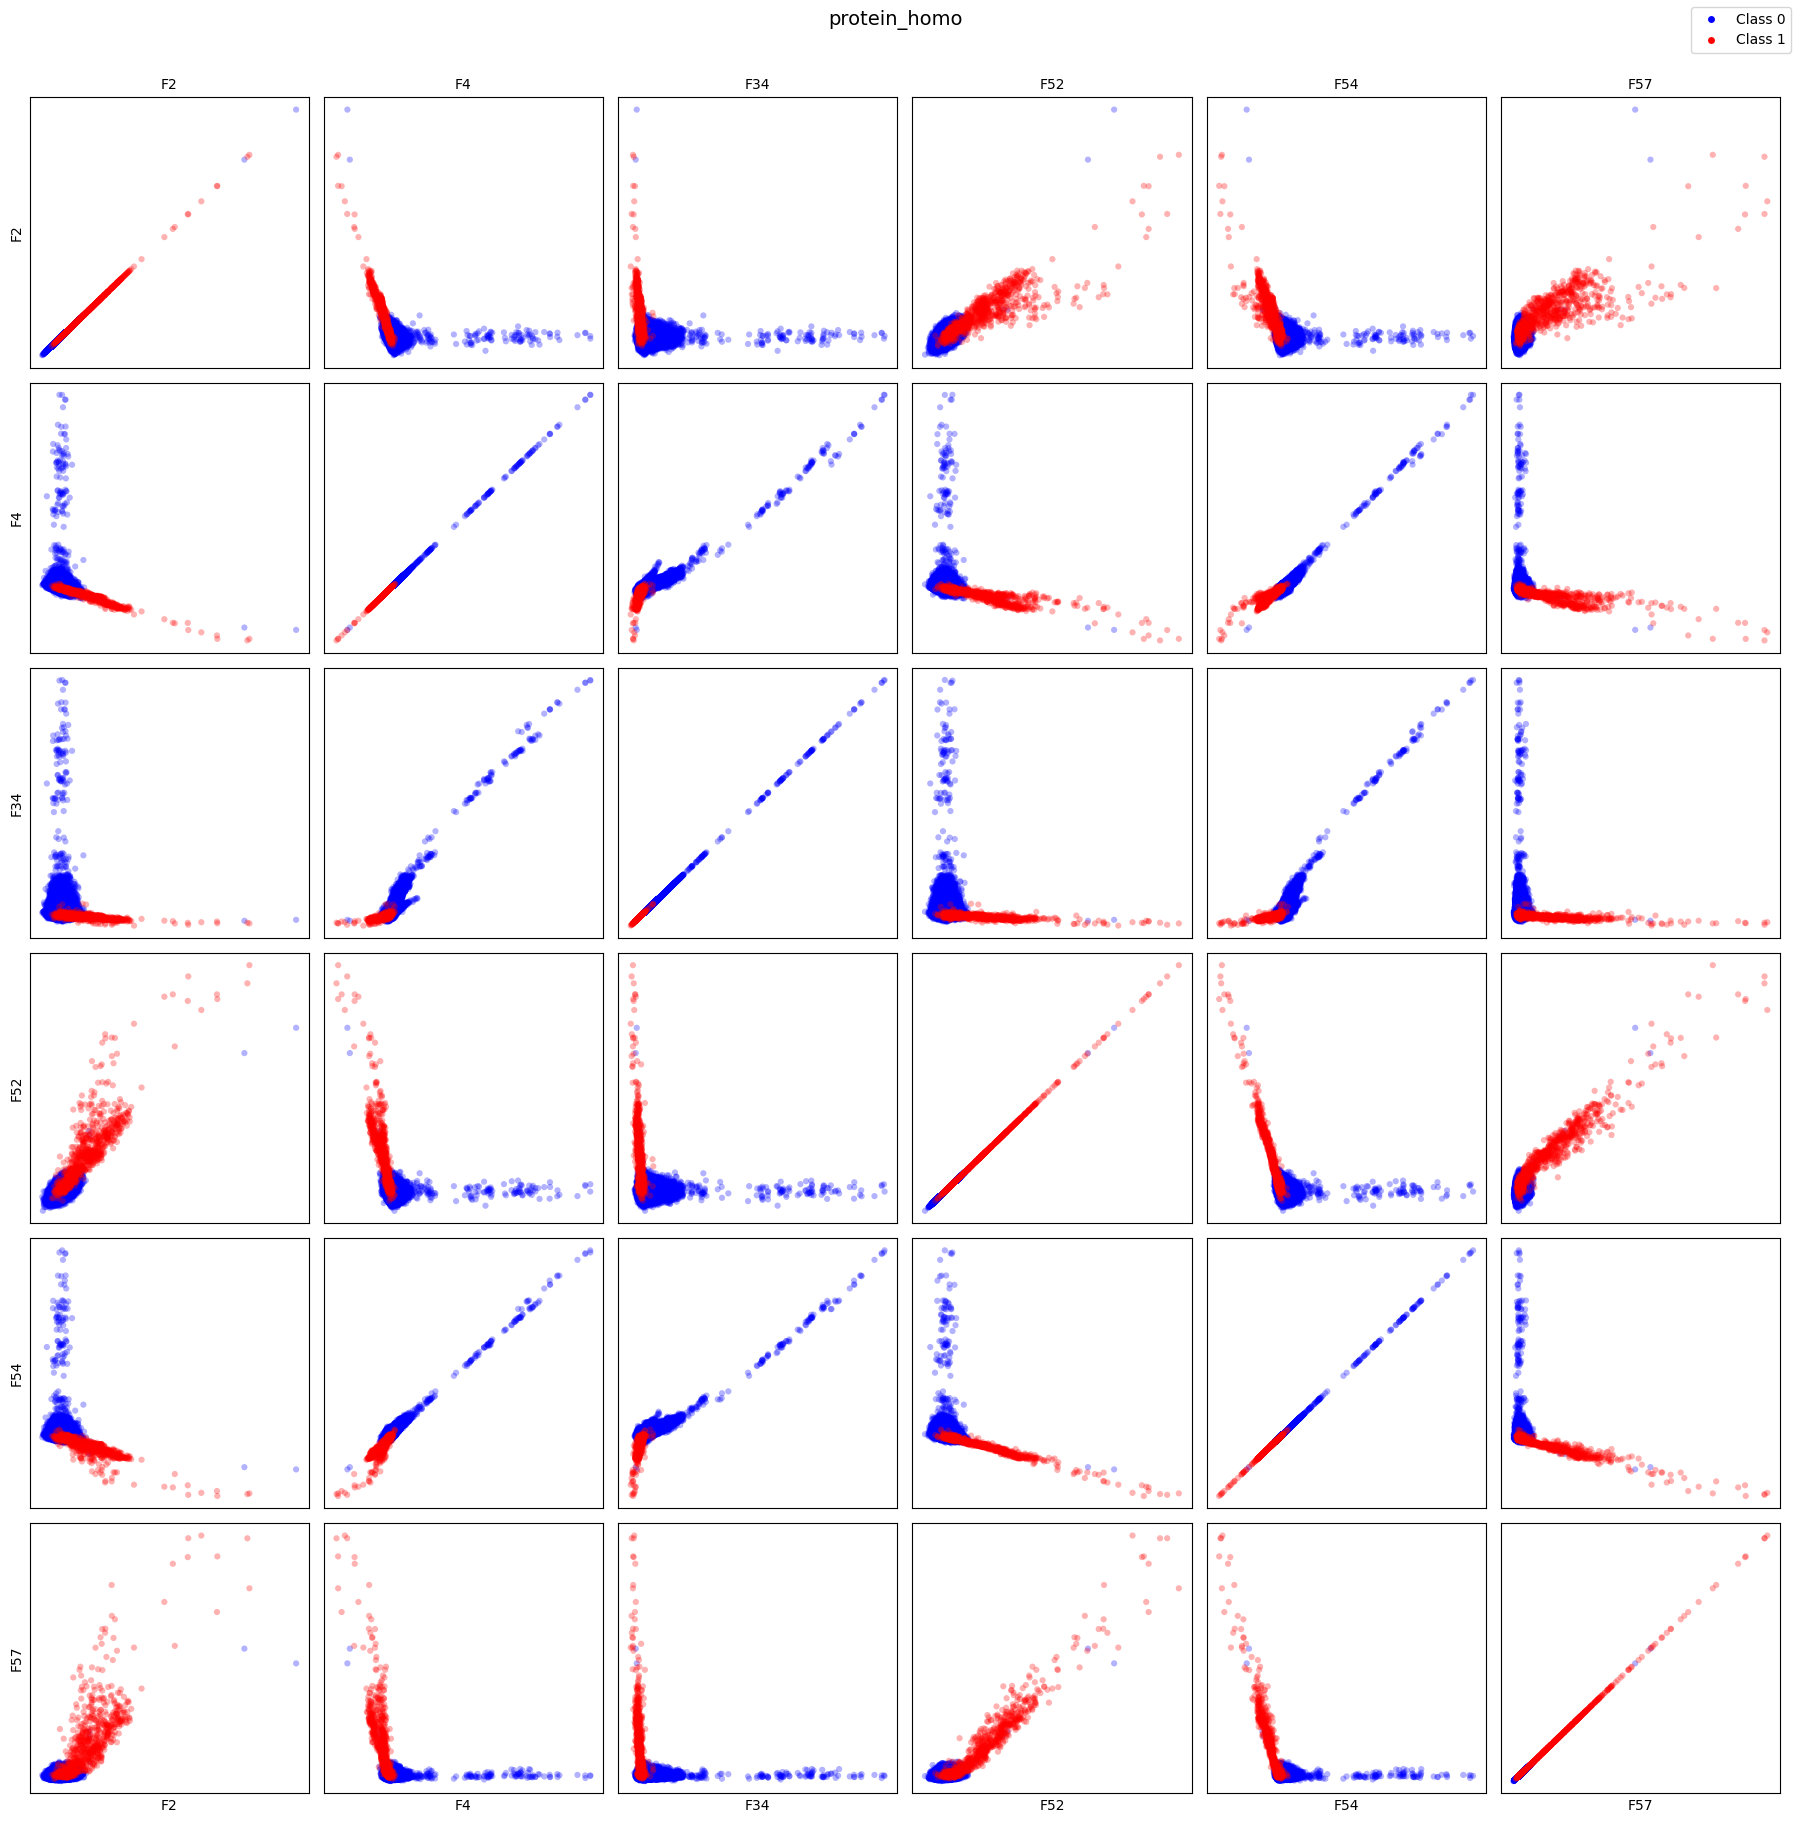

In [6]:
for dataset in datasets:
    X_train, X_test, y_train, y_test = load_dataset(dataset)
    
    # find good features
    good_features = []
    for j in range(X_train.shape[1]):
        col = X_train.iloc[:, j] if hasattr(X_train, "iloc") else X_train[:, j]
        auc = roc_auc_score(y_train, col)
        auc = max(auc, 1 - auc)
        if auc >= threshold:
            feat_name = X_train.columns[j] if hasattr(X_train, "columns") else j
            good_features.append((feat_name, round(auc, 3)))
    if not good_features:
        print(f"{dataset}: no good features, skipping.")
        continue

    # Scatter plots
    feat_names = [f[0] for f in good_features]
    n = len(feat_names)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    if n == 1:
        axes = np.array([[axes]])
    for i, fi in enumerate(feat_names):
        for j, fj in enumerate(feat_names):
            ax = axes[i, j]
            for label, color in zip([0, 1], ["blue", "red"]):
                mask = y_train == label
                xi = X_train.iloc[mask, X_train.columns.get_loc(fi)] if hasattr(X_train, "iloc") else X_train[mask, fi]
                xj = X_train.iloc[mask, X_train.columns.get_loc(fj)] if hasattr(X_train, "iloc") else X_train[mask, fj]
                ax.scatter(xj, xi, c=color, edgecolor="none", alpha=0.3, s=20)
            if i == n - 1:
                ax.set_xlabel(f"F{fj}", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"F{fi}", fontsize=10)
            if i == 0:
                ax.set_title(f"F{fj}", fontsize=10)
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, label=f"Class {l}")
               for l, c in zip([0, 1], ["blue", "red"])]
    fig.legend(handles=handles, loc="upper right", fontsize=10)
    plt.suptitle(f"{dataset}", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()